# 1. Trabajando con datos de texto

## 1.1. Tokenizar el texto

In [1]:
#from datasets import load_dataset
#Dataset de SQL en inglés
#ds_pro = load_dataset("Clinton/Text-to-SQL-v1", split="train")
#print(f"Dataset robusto cargado. Tiene {len(ds_pro)} ejemplos.")

In [50]:
import re
import unicodedata

def tokenize_quijote(text):
    text = unicodedata.normalize('NFC', text)
    
    token_pattern = r'''(?x)
        (?:[A-Z]\.)+                        # Siglas (D., J.C.)
        | \d+(?:[.\s]\d{3})*(?:,\d+)?%?     # Números
        | [a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]+           # Palabras (con tildes y eñes ya normalizadas)
        | \.\.\.                            # Puntos suspensivos
        | [¿?¡!(),;.:]                      # Puntuación básica
    '''
    return re.findall(token_pattern, text)

with open('Datasets/el_quijote.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read()

tokens = tokenize_quijote(raw_text)

print(tokens[10:30])

['PARTE', 'CAPÍTULO', '1', ':', 'Que', 'trata', 'de', 'la', 'condición', 'y', 'ejercicio', 'del', 'famoso', 'hidalgo', 'D.', 'Quijote', 'de', 'la', 'Mancha', 'En']


In [51]:
preprocesado = tokens

In [52]:
len(preprocesado)

213745

## 1.2. Convertir los Tokens en IDs

In [53]:
#Quitar duplicados para crear vocabulario
all_words = sorted(set(preprocesado))
vocab_size = len(all_words)
print(vocab_size)

15349


In [54]:
print(all_words[0:1000])

['!', '(', ')', ',', '.', '...', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '6', '7', '8', '9', ':', ';', '?', 'A', 'ACADÉMICO', 'ACADÉMICOS', 'ANTONIO', 'ARGAMASILLA', 'ARGAMASILLESCO', 'Abalánzase', 'Abencerraje', 'Abindarráez', 'Abrazáronse', 'Abrazóla', 'Abrazóle', 'Abrila', 'Abriéle', 'Abrió', 'Abrióle', 'Abrióse', 'Absorto', 'Acaba', 'Acabado', 'Acabamos', 'Acabando', 'Acabaron', 'Acabe', 'Acabó', 'Acabóse', 'Acaeció', 'Acertó', 'Acomodóse', 'Aconsejaba', 'Aconsejóle', 'Acordamos', 'Acudid', 'Acudieron', 'Acudió', 'Acudí', 'Acullá', 'Acuérdome', 'Acá', 'Adelante', 'Admirada', 'Admirado', 'Admirados', 'Admirándose', 'Admiráronse', 'Admiró', 'Admiróse', 'Advertido', 'Advierta', 'Advierte', 'Adán', 'Adóbame', 'Adónde', 'Afligióse', 'Agi', 'Agora',

In [55]:
#Asignar un entero único a cada tokeN
vocab = {token:integer for integer, token in enumerate(all_words)}
len(vocab)

15349

In [56]:
#Vamos a encodear todo el texto con los identificadores del vocabulario
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}
        
    def encode(self, text):
        #Usamos la función de tokenización específica
        preprocesado = tokenize_quijote(text)
        #Si la palabra es una clave del diccionario (es decir, está registrada) la deja.
        #Si hay un carácter en el texto que no tiene en ninguna clave del diccionario le pone el auxiliar <|unk|> 
        preprocesado = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocesado
        ]
        #Convertimos a IDs usando el vocabulario
        ids = [self.str_to_int[s] for s in preprocesado]
        return ids
        
    def decode(self, ids):
        #Convertimos IDs a palabras
        tokens = [self.int_to_str[i] for i in ids]
        
        #Unimos con espacios
        text = " ".join(tokens)
        
        #Quitamos espacios innecesarios antes de la puntuación
        #Se añaden los signos de exclamación e interrogación de cierre y puntos
        text = re.sub(r'\s+([,.?!:;\]\)])', r'\1', text)
        
        #Quitamos los espacios después de signos de apertura
        text = re.sub(r'([¿¡\(\[])\s+', r'\1', text)
        
        return text

In [57]:
tokenizer = SimpleTokenizerV1(vocab)

In [58]:
text = "Decía él, que el Cid Ruy Díaz había sido muy buen caballero; pero que no tenía que ver con el caballero de la ardiente espada, que de sólo un revés había partido por medio dos fieros y descomunales gigantes. Mejor estaba con Bernardo del Carpio, porque en Roncesvalle había muerto a Roldán el encantado, valiéndose de la industria de Hércules, cuando ahogó a Anteo, el hijo de la Tierra, entre los brazos. Decía mucho bien del gigante Morgante, porque con ser de aquella generación gigantesca, que todos son soberbios y descomedidos, él solo era afable y bien criado; pero sobre todos estaba bien con Reinaldos de Montalbán, y más cuando le veía salir de su castillo y robar cuantos topaba, y cuando en Allende robó aquel ídolo de Mahoma, que era todo de oro, según dice su historia. Diera él, por dar una mano de coces al traidor de Galalón, al ama que tenía y aun a su sobrina de añadidura."

In [59]:
ids = tokenizer.encode(text)

In [60]:
print(ids)

[489, 15307, 3, 12188, 6594, 382, 1472, 587, 8387, 13544, 10461, 3754, 3824, 59, 11409, 12188, 10597, 14170, 12188, 14920, 4567, 6594, 3824, 5366, 9215, 3013, 7345, 3, 12188, 5366, 14000, 14680, 12911, 8387, 11112, 11699, 9978, 6395, 7810, 15223, 5716, 8127, 4, 1075, 7431, 4567, 284, 5521, 350, 3, 11710, 6681, 1462, 8387, 10417, 1815, 1460, 6594, 6729, 3, 14753, 5366, 9215, 8968, 5366, 880, 3, 5159, 2436, 1815, 191, 3, 6594, 8615, 5366, 9215, 1633, 3, 7059, 9665, 3730, 4, 489, 10383, 3637, 5521, 8126, 1125, 3, 11710, 4567, 13471, 5366, 2982, 8110, 8128, 3, 12188, 14278, 13773, 13654, 15223, 5707, 3, 15307, 13744, 7147, 2305, 15223, 3637, 5108, 59, 11409, 13659, 14278, 7431, 3637, 4567, 1418, 5366, 1117, 3, 15223, 10475, 5159, 9293, 14985, 13238, 5366, 13833, 4101, 15223, 12980, 5163, 14325, 3, 15223, 5159, 6681, 155, 12987, 2981, 15326, 5366, 1025, 3, 12188, 7147, 14277, 5366, 10879, 3, 13401, 6129, 13833, 8634, 4, 542, 15307, 3, 11699, 5341, 14681, 9856, 5366, 4354, 2465, 14432, 5366,

In [61]:
tokenizer.decode(ids)

'Decía él, que el Cid Ruy Díaz había sido muy buen caballero; pero que no tenía que ver con el caballero de la ardiente espada, que de sólo un revés había partido por medio dos fieros y descomunales gigantes. Mejor estaba con Bernardo del Carpio, porque en Roncesvalle había muerto a Roldán el encantado, valiéndose de la industria de Hércules, cuando ahogó a Anteo, el hijo de la Tierra, entre los brazos. Decía mucho bien del gigante Morgante, porque con ser de aquella generación gigantesca, que todos son soberbios y descomedidos, él solo era afable y bien criado; pero sobre todos estaba bien con Reinaldos de Montalbán, y más cuando le veía salir de su castillo y robar cuantos topaba, y cuando en Allende robó aquel ídolo de Mahoma, que era todo de oro, según dice su historia. Diera él, por dar una mano de coces al traidor de Galalón, al ama que tenía y aun a su sobrina de añadidura.'

## 1.3 Añadir tokens especiales de contexto

In [62]:
all_tokens = sorted(list(set(preprocesado)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab = {token:integer for integer, token in enumerate(all_tokens)} 

In [63]:
tokenizer2 = SimpleTokenizerV1(vocab)

In [64]:
len(vocab)

15351

In [65]:
#En esta frase hay palabras fuera de nuestro vocabulario del tokenizador, saltará error <|unk|>
text = "Hola, esto es un trabajo. Voy a realizar una prueba"
ids = tokenizer2.encode(text)
print(ids)

[15350, 3, 7489, 7165, 14680, 14391, 4, 15350, 1815, 15350, 14681, 12065]


In [66]:
tokenizer2.decode(ids)

'<|unk|>, esto es un trabajo. <|unk|> a <|unk|> una prueba'

## 1.4 Byte pair encoding

El BPE nos permitirá gestionar términos desconocidos por el modelo. 
Nombres que no han sido incluidos en el vocabulario de entrenamiento.
Rompería la palabra desconocida en subtokens.

El vocabulario de los subtokens reconocido por el modelo se utilizará, sin embargo, todos aquellos subtokens que no signifiquen nada los romperá en carácteres individuales para no ensuciar el contexto.

Para este ejemplo utilizaremos una librería de python desarrollada por OpenAI llamada Tiktoken, muy eficiente debido a que tiene código implementado en Rust. De esta forma utilizaremos el tokenizer de GPT2.

In [67]:
import tiktoken

In [68]:
tiktoken.__version__

'0.12.0'

In [69]:
tokenizer = tiktoken.get_encoding("gpt2")

In [70]:
textoprueba = tokenizer.encode("Hola mundo")
print(textoprueba)

[39, 5708, 27943, 78]


In [71]:
tokenizer.decode(textoprueba)

'Hola mundo'

In [72]:
#Explicación de el token especial <|endoftext|>
#El token <|endoftext|> es muy utilizado a la hora de delimitar en el entrenamiento del modelo cuando acaba un documento y empieza otro 
#para que la concatenación en el cerebro del modelo sea precisa.
#Salta error debido a que por defecto este token especial no está permitido en el tokenizador de gpt2, por lo que lo tenemos que habilitar.
#Este tokenizer utiliza el mecanismo BPE y por eso no salta error con asdasjdfd

text = "Hola, este es mi trabajo final. <|endoftext|> En un lugar de la mancha de cuyo nombre no quiero acordarme. asdasjdfd"
print(tokenizer.encode(text, allowed_special={"<|endoftext|>"}))

[39, 5708, 11, 43577, 1658, 21504, 491, 397, 34944, 2457, 13, 220, 50256, 2039, 555, 300, 35652, 390, 8591, 582, 11693, 390, 269, 4669, 78, 299, 2381, 260, 645, 627, 959, 78, 936, 585, 283, 1326, 13, 355, 67, 292, 73, 7568, 67]


## 1.5 Muestreo de datos con ventana deslizante

Este apartado mostrará como podemos proveer al modelo con varios de estos tokenIDs para entrenarlo.

Uno de los objetivos más claros de los LLMs es predecir token a token. Siendo el input del modelo la parte azul y la predicción la parte roja.

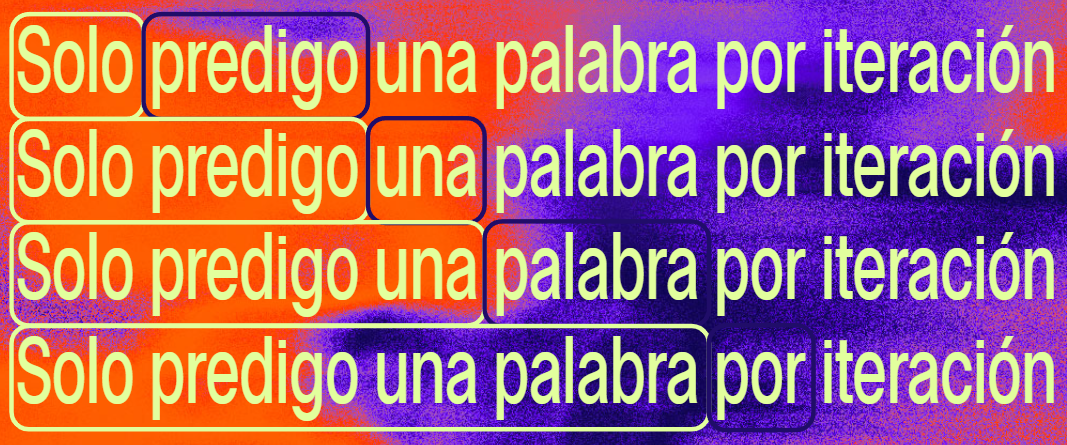

In [73]:
#Vamos a encodear El Quijote con nuestro tokenizador de gpt2
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

411861


In [74]:
enc_sample = enc_text[400000:]

In [75]:
ventana_contexto = 4

x = enc_sample[:ventana_contexto]
y = enc_sample[1:ventana_contexto+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [390, 17266, 136, 223]
y:      [17266, 136, 223, 82]


Si el modelo recibe los tokens x debe de predecir el siguiente (el 82), y así recursivamente cogiendo 4 como contexto, pues una vez predicho el nuevo token pasaría a x y y contendría el siguiente.

In [76]:
import torch

Utilizaremos la librería Pytorch para realizar este muestreo de datos con ventana deslizante.

In [77]:
torch.__version__

'2.4.1+cpu'

In [78]:
#pip install torch==2.6.0

In [79]:
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids=[]
        self.target_ids=[]

        token_ids = tokenizer(txt, add_special_tokens=False)["input_ids"]
        
        #Utilizo una ventana deslizante para partir El Quijote en secuencias de max_length tokens
        #El stride determina cuánto se desplaza la ventana deslizante, la "zancada"
        for i in range(0, len(token_ids) - max_length, stride):
            
            input_chunck = token_ids[i : i+max_length]
            target_chunck = token_ids[i+1 : i+max_length+1]

            #Listas de tensores de Pytorch con las secuencias
            self.input_ids.append(torch.tensor(input_chunck))
            self.target_ids.append(torch.tensor(target_chunck))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [80]:
!uv pip install transformers

Checked 1 package in 10ms


In [81]:
#El DataLoader gestiona cómo se entregan los datos al modelo durante el entrenamiento.
#Como el max_length es 256 (contexto) y el stride (salto) es 128, hay un solapamiento del 50%
from transformers import AutoTokenizer

def crea_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    
    #Inicializamos el tokenizer
    model_name = "dccuchile/bert-base-spanish-wwm-cased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    #Creamos el dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    #Creamos el dataloader
    dataloader = DataLoader(
        dataset,
        #El modelo no lee todo el libro a la vez, sino que procesa 4 fragmentos simultáneamente en cada paso.
        batch_size=batch_size,
        shuffle=shuffle,
        #Elimina el resto de la división entre el dataset entero y el max_length, ya que quedará un contexto de distinto tamaño al final y perjudicará los resultados finales
        drop_last=drop_last,
        #No habrá procesos en paralelo para evitar posibles errores
        num_workers=num_workers
    )
    return dataloader

In [82]:
dataloader = crea_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=2, shuffle=False
)

data_iter = iter(dataloader)
input1, target1 = next(data_iter)
print(input1)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (240703 > 512). Running this sequence through the model will result in indexing errors


tensor([[ 2427, 30969, 14246, 30977],
        [14246, 30977,   992, 15875],
        [  992, 15875, 30956,  1982],
        [30956,  1982,  3655, 16554],
        [ 3655, 16554, 12216, 30963],
        [12216, 30963,  7793,  1008],
        [ 7793,  1008, 21973,  1543],
        [21973,  1543,  3053,  9723]])


In [83]:
print(target1)

tensor([[30969, 14246, 30977,   992],
        [30977,   992, 15875, 30956],
        [15875, 30956,  1982,  3655],
        [ 1982,  3655, 16554, 12216],
        [16554, 12216, 30963,  7793],
        [30963,  7793,  1008, 21973],
        [ 1008, 21973,  1543,  3053],
        [ 1543,  3053,  9723,  4397]])


In [84]:
input2, target2 = next(data_iter)
print(input2)

tensor([[ 3053,  9723,  4397, 24366],
        [ 4397, 24366, 15253, 28395],
        [15253, 28395,     3,  1094],
        [    3,  1094,  1181,  1872],
        [ 1181,  1872,  3013,  1008],
        [ 3013,  1008,  1030,     3],
        [ 1030,     3,  1042,  4376],
        [ 1042,  4376,  1072,  8924]])


In [85]:
print(target2)

tensor([[ 9723,  4397, 24366, 15253],
        [24366, 15253, 28395,     3],
        [28395,     3,  1094,  1181],
        [ 1094,  1181,  1872,  3013],
        [ 1872,  3013,  1008,  1030],
        [ 1008,  1030,     3,  1042],
        [    3,  1042,  4376,  1072],
        [ 4376,  1072,  8924,  1563]])


## 1.6 Creando Token Embeddings

Ahora nos centraremos en la última parte, los embeddings.
Básicamente son la transformación de cada uno de los tokenIDs en vectores de números.

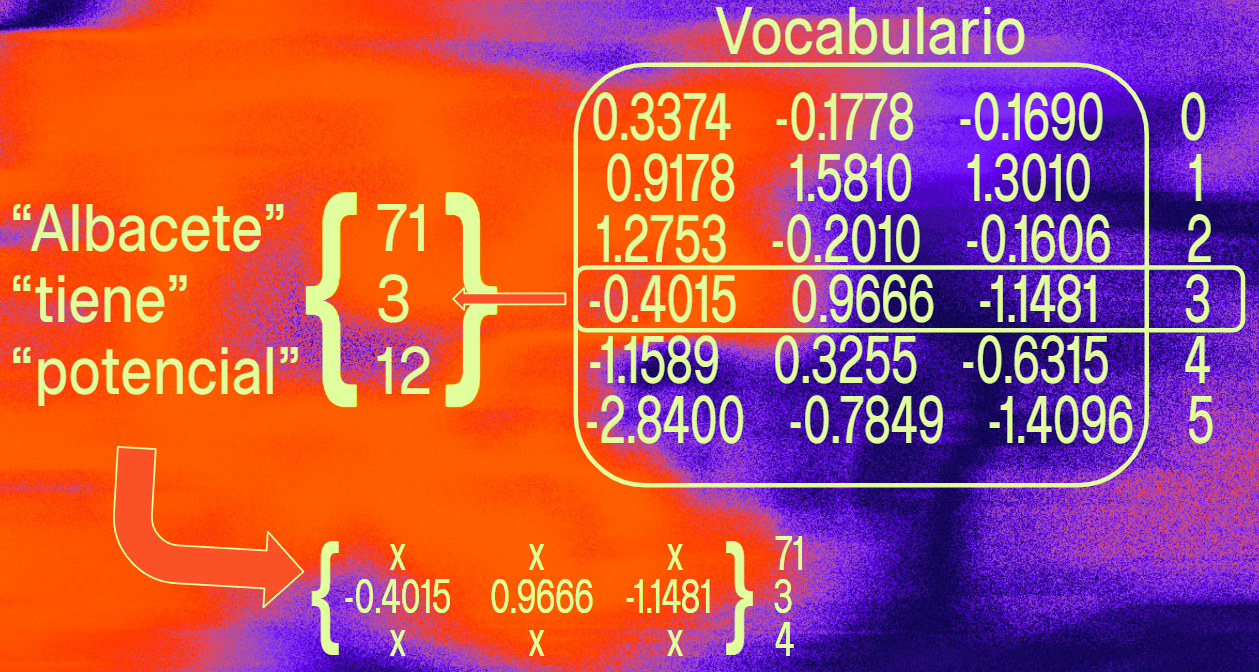

In [86]:
vocab_size = tokenizer.n_vocab
output_dim = 256

torch.manual_seed(123)
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [87]:
print(token_embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.3035,  ...,  1.3337,  0.0771, -0.0522],
        [ 0.2386,  0.1411, -1.3354,  ..., -0.0315, -1.0640,  0.9417],
        [-1.3152, -0.0677, -0.1350,  ..., -0.3181, -1.3936,  0.5226],
        ...,
        [ 0.5871, -0.0572, -1.1628,  ..., -0.6887, -0.7364,  0.4479],
        [ 0.4438,  0.7411,  1.1263,  ...,  1.2091,  0.6781,  0.3331],
        [-0.2537,  0.1446,  0.7203,  ..., -0.2134,  0.2144,  0.3006]],
       requires_grad=True)


In [88]:
# El embed que pertenece a la posicion 4 que pertenece al tokenID de una palabra del vocabulario del tokenizador de gpt2
token_embedding_layer(torch.tensor([3]))

tensor([[ 0.2579,  0.3420, -0.8168,  1.6772, -0.8353,  0.7531,  0.0821,  1.1650,
         -0.6635, -0.7809, -0.2270, -0.4358,  0.8209, -0.6353, -0.4386, -0.4472,
          1.5098, -0.0783,  0.7707,  0.5180,  0.2458,  0.3937, -0.7882,  0.3228,
         -0.7447,  0.3102, -1.4619, -0.1745, -0.5482, -0.4097, -0.0627,  0.0175,
          1.3715, -0.2226,  1.0566,  0.3687,  1.8359,  1.2957,  0.8045, -0.6188,
         -1.1795,  0.3383,  0.9319,  0.7436,  0.2490, -1.3814, -0.7985,  0.6369,
         -1.5530, -1.6292,  0.6107,  1.2718, -0.9422, -0.2667, -0.3216,  0.4504,
          0.3718,  0.6457,  0.5804,  0.3752,  0.4293, -0.7276, -0.5527,  0.6189,
         -1.4284,  0.5617,  0.7701,  0.3566, -0.1267,  0.9447,  0.1466,  0.2673,
          0.9467, -0.1406,  0.0329, -2.1542,  1.3953,  1.1845, -0.1255,  0.2517,
          1.3081,  0.1495,  1.1315,  0.2044,  1.2430, -0.0409,  0.7491,  0.3026,
         -0.7591, -0.9542, -1.6160, -0.1016, -1.1510, -1.8215,  1.1655, -2.3307,
          0.5062, -1.5363, -

In [89]:
print("Token IDs:\n", input2)
print("\nInputs shape:\n", input2.shape)

Token IDs:
 tensor([[ 3053,  9723,  4397, 24366],
        [ 4397, 24366, 15253, 28395],
        [15253, 28395,     3,  1094],
        [    3,  1094,  1181,  1872],
        [ 1181,  1872,  3013,  1008],
        [ 3013,  1008,  1030,     3],
        [ 1030,     3,  1042,  4376],
        [ 1042,  4376,  1072,  8924]])

Inputs shape:
 torch.Size([8, 4])


Ahora queremos convertir estas secuencias de tokenIDs a secuencias de embeddings, es decir, convertir cada tokenID en su respectivo embed.

In [90]:
token_embeddings = token_embedding_layer(input2)
token_embeddings.shape

torch.Size([8, 4, 256])

In [91]:
token_embeddings

tensor([[[ 0.1400,  0.6239, -1.6817,  ..., -1.6924,  0.1082, -0.4367],
         [-0.5453,  0.8678,  0.9522,  ...,  0.1488,  0.8899, -0.6967],
         [-1.8769, -0.2539,  1.3474,  ..., -0.4116, -0.6617,  0.7708],
         [-0.0234, -0.0760, -0.2425,  ..., -0.1189,  0.4955, -0.9737]],

        [[-1.8769, -0.2539,  1.3474,  ..., -0.4116, -0.6617,  0.7708],
         [-0.0234, -0.0760, -0.2425,  ..., -0.1189,  0.4955, -0.9737],
         [ 0.5397,  1.6641,  0.9548,  ...,  0.8858, -0.2315,  1.3806],
         [ 0.6536,  0.0309,  0.0160,  ..., -0.9906, -0.9223,  0.3454]],

        [[ 0.5397,  1.6641,  0.9548,  ...,  0.8858, -0.2315,  1.3806],
         [ 0.6536,  0.0309,  0.0160,  ..., -0.9906, -0.9223,  0.3454],
         [ 0.2579,  0.3420, -0.8168,  ..., -0.4840, -0.2713, -0.0774],
         [-0.3087,  0.5860,  0.9629,  ..., -0.5776,  0.8355,  1.8644]],

        ...,

        [[-0.1899,  1.2331,  0.7238,  ...,  0.9936, -0.1914,  0.2380],
         [-0.3836, -0.6470,  0.8649,  ...,  0.1072,  0.67

## 1.7 Codificando la posición de palabras

El siguiente paso sería añadir información posicional.

Si tuviéramos la misma palabra repetida en la misma secuencia el embed sería el mismo ya que su tokenID refiere a la misma fila de pesos de la capa de embedding.
Por este motivo, se utiliza otra capa de embeddings posicionales para que dependiendo de la posición obtengamos distinto input. El input final será la suma de los embed de tokenIDs y los embed posicionales.

In [92]:
context_length = 4
pos_embedding_layer = torch.nn.Embedding(context_length,output_dim)

In [93]:
torch.arange(context_length)

tensor([0, 1, 2, 3])

In [94]:
pos_embedding_layer.weight

Parameter containing:
tensor([[ 0.5423, -0.1224, -1.4150,  ...,  0.2515, -2.3067,  0.8155],
        [-0.3973, -1.2575, -1.9800,  ..., -0.1207,  0.3075, -0.6422],
        [ 0.1840,  1.1128,  1.0052,  ...,  0.2081,  0.5531, -1.1619],
        [ 1.4155,  0.6599,  0.3760,  ...,  0.7034, -0.6108,  0.1080]],
       requires_grad=True)

In [95]:
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [96]:
token_embeddings.shape

torch.Size([8, 4, 256])

In [97]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


# Metodología: Pipeline de Procesamiento de Entrada

En el desarrollo de este proyecto, se ha implementado y completado un pipeline de preprocesamiento de lenguaje natural (NLP) encargado de transformar el texto plano en representaciones vectoriales aptas para el modelo. Este proceso es fundamental para que la arquitectura pueda interpretar tanto el significado semántico como la estructura secuencial de la información.

A continuación, se detallan las fases completadas del pipeline:

## 1. Tokenización y Mapeo de Identificadores
El flujo comienza con la recepción del **Input Text**. Este se segmenta en unidades mínimas denominadas tokens (**Tokenized text**). Tras la segmentación, cada token se traduce a su correspondiente valor numérico (**Token IDs**) consultando el vocabulario del modelo. Este paso permite convertir datos categóricos (palabras) en datos numéricos con los que la red neuronal puede operar.

## 2. Generación de Token Embeddings
Cada identificador se proyecta en un espacio latente de alta dimensión para generar los **Token Embeddings**. Estos vectores capturan la semántica de la palabra; sin embargo, al procesarse de forma paralela en la arquitectura, la información sobre la posición absoluta del token se pierde en esta etapa.

## 3. Codificación Posicional (Positional Embeddings)
Para reintroducir el orden secuencial necesario para la comprensión gramatical, se han generado **Positional Embeddings**. Estos vectores se calculan para cada posición del índice y permiten que el modelo distinga entre la misma palabra ubicada en diferentes partes de la secuencia.

## 4. Obtención de los Input Embeddings Finales
La etapa final del pipeline consiste en la suma de los vectores de tokens y los vectores posicionales:

$$E_{final} = E_{token} + E_{positional}$$

El resultado son los **Input Embeddings**, una representación vectorial que combina el significado léxico con la ubicación contextual. Estos vectores finales constituyen la entrada directa a las capas de atención del transformador.